<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Projects/County-Health-Choropleth/CHR-MATERNAL-HEALTH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  $\color{blue}{Problem \ Statement: County Health Ranking 2025 Data}$

What social and environmental factors predict low birthweight across urban
and rural counties? Using CHR Maternal Health data, this analysis applies two
models to several structured features: a regression on the continuous target
`low_birthweight_pct`, and a Gaussian Naive Bayes classifier on the binary
target `high_lbw` (a median split of that same value).

- **Regression target (y):** `low_birthweight_pct` (v037_rawvalue)
- **Classification target (y):** `high_lbw` (median split of v037_rawvalue)


**Features X equal** =

1. "v125_rawvalue": "air_pollution_pm25",
2.    "v015_rawvalue": "homicide_rate", 2025 violence proxy (violent crime v043 was dropped) MNAR replaced by 'homicide_suppresed' flag.
3.    "v138_rawvalue": "drug_overdose_deaths",
4.    "v148_rawvalue": "firearm_fatalities",
5.    "v009_rawvalue": "adult_smoking_pct",
6.    "v024_rawvalue": "children_in_poverty_pct",
7.    "v063_rawvalue": "median_household_income",
8.    "v058_rawvalue": "pct_rural",
9.    "v085_rawvalue": "uninsured_pct"

Four additional missingness flags were engineered:

a. homicide_suppressed,
b. drug_overdose_missing,
c. firearm_missing,
d. air_pollution_pm25_missing

In [2]:
import pandas as pd, numpy as np, requests, os

URL = "https://www.countyhealthrankings.org/sites/default/files/media/document/analytic_data2025_v3.csv"
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                         "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"}

MEASURE_IDS = {
    "v037_rawvalue": "low_birthweight_pct",   # TARGET
    "v125_rawvalue": "air_pollution_pm25",
    "v015_rawvalue": "homicide_rate",         # 2025 violence proxy (violent crime v043 was dropped)
    "v138_rawvalue": "drug_overdose_deaths",
    "v148_rawvalue": "firearm_fatalities",
    "v009_rawvalue": "adult_smoking_pct",
    "v024_rawvalue": "children_in_poverty_pct",
    "v063_rawvalue": "median_household_income",
    "v058_rawvalue": "pct_rural",
    "v085_rawvalue": "uninsured_pct",
}

def get_chr(path="chr_analytic.csv"):
    if not os.path.exists(path):
        r = requests.get(URL, headers=HEADERS, timeout=60); r.raise_for_status()
        open(path, "wb").write(r.content); print("Downloaded", len(r.content)//1024, "KB")
    raw = pd.read_csv(path, dtype=str, low_memory=False)
    raw.columns = [str(c).strip() for c in raw.columns]
    if "fipscode" not in raw.columns:                      # 2025 has a 2nd header row
        row0 = raw.iloc[0].astype(str).str.strip()
        if "fipscode" in set(row0):
            raw.columns = row0.values
            raw = raw.iloc[1:].reset_index(drop=True)
            print("Promoted measure-code row to header.")
    return raw

def clean_chr(path="chr_analytic.csv"):
    raw = get_chr(path)
    present = {v: n for v, n in MEASURE_IDS.items() if v in raw.columns}
    if not present:
        raise RuntimeError("No measure columns found — check the file header.")
    keep = [c for c in ["fipscode", "state", "county"] if c in raw.columns] + list(present)
    out = raw[keep].rename(columns=present)
    for n in present.values():
        out[n] = pd.to_numeric(out[n], errors="coerce")
    fips = out["fipscode"].astype(str).str.zfill(5)
    out = out[(fips != "00000") & (~fips.str.endswith("000"))].copy()   # drop US + state rollups
    if out["low_birthweight_pct"].notna().any() and out["low_birthweight_pct"].max() <= 1:
        out["low_birthweight_pct"] *= 100
    out = out.dropna(subset=["low_birthweight_pct"]).reset_index(drop=True)
    out["high_lbw"] = (out["low_birthweight_pct"] > out["low_birthweight_pct"].median()).astype(int)
    return out

df = clean_chr()
print(df.shape)
df.describe()

Downloaded 12778 KB
Promoted measure-code row to header.
(3043, 14)


,low_birthweight_pct,air_pollution_pm25,homicide_rate,drug_overdose_deaths,firearm_fatalities,adult_smoking_pct,children_in_poverty_pct,median_household_income,pct_rural,uninsured_pct,high_lbw
count,3043.000000,2975.000000,1418.000000,2001.000000,2297.000000,3035.000000,3035.000000,3035.000000,3035.000000,3035.000000,3043.000000
mean,8.418943,7.702588,8.162641,32.780628,17.826850,0.180162,0.190436,65522.254366,0.629905,0.104467,0.499836
std,2.130744,1.988148,6.981581,19.150597,8.444965,0.039004,0.081073,16587.659198,0.334840,0.046115,0.500082
min,2.908277,1.300000,0.657630,5.100922,1.859280,0.059000,0.031000,28579.000000,0.000000,0.021492,0.000000
25%,6.984426,6.600000,3.782233,19.603511,12.114044,0.156000,0.131000,54556.000000,0.348103,0.069186,0.000000
50%,8.115942,7.700000,6.174228,28.509730,16.648258,0.178000,0.179000,62834.000000,0.645958,0.094131,0.000000
75%,9.341623,8.500000,10.095436,39.949987,22.019157,0.204000,0.234500,73042.500000,1.000000,0.131362,1.000000
max,22.580645,39.100000,57.439668,180.692277,79.459203,0.383000,0.632000,173655.000000,1.000000,0.348205,1.000000


## Data Check

Data Frame check:
-  df = clean_chr()

-  print(df.shape)

-  print(df.describe())

Count is missingness map.  Total is 3,043 subtract count of catagory from each header to determine what values are missing in each column header.

1. low_birthweight_pct — 3043 ✓ full
2. air_pollution_pm25 — 2975 ( missing 68) 2.2%
3. homicide_rate — 1418 ( missing 1,625) 53.4%
4. drug_overdose_deaths — 2001 ( missing 1,042) 34.2%
5 .firearm_fatalities — 2297  ( missing 746) 24.5%

The confounders (smoking, poverty, income, rural, uninsured) — 3035 each (8 missing) 0.3%. per coloumn
1. adult_smoking_pct (missing 8)
2. children_in_poverty_pct (missing 8)
3. median_household_income (missing 8)
4. pct_rural (missing 8)
5. uninsured_pct (mising 8)
6. high_lbw — 3043 ✓ (derived from the target which is full)



---



| Metric | Homicide Rate | Drug Overdose Deaths |
| :--- | :--- | :--- |
| **How much real data?** | 47% — too little | 66% — enough to anchor imputation |
| **Missingness direction** | Strongly value-related (suppressed at low end) → imputing biases upward | Weaker directional bias; indicator column keeps it honest |
| **Decision** | Drop continuous, keep flag | Impute + missingness indicator |
| **Missingness Indicator** | Column keeps it honest | Impute + missingness indicator |

### Why homicide and drug overdose are handled differently

Two conditions drive the decision for each column: how much real data
remains, and whether the missingness points in a known direction.

- **homicide_rate** is missing because CHR suppresses small counts to
protect privacy in low-population counties. The blanks therefore cluster
at the low end of the range (near-zero homicides). This is missing not at random (MNAR) — the
value is missing *because* it is small. Imputing the median would invent
moderate violence for quiet rural counties, biasing the model upward.
With only 47% real data AND a known directional bias, we drop the
continuous column and keep a `homicide_suppressed` flag — recording
*that* it was suppressed rather than pretending to know the value.

- **drug_overdose_deaths** retains 66% real observations. Its missingness
has a weaker directional bias, and the 2-to-1 majority of real values can
anchor an imputation. We impute AND add a missingness indicator column,
so the model can see which rows were filled rather than being silently
misled. The indicator keeps us honest about the fact that the missing
counties are not a representative sample.

## Note
Use Max to idnetify the scale and change if a porportion is max < 1.0 no lower bound.   Make everything the same units or scale for modeling.

### Unit Reconciliation

Use the **max** (not the mean) to identify a column's scale — max reveals
the ceiling, and a proportion can never exceed 1.0.

- If a column's **max ≤ 1.0**, it is a proportion (0–1). Multiply by 100 to
  convert it to a percent.
- If a column's **max is a large number** (e.g. 22, 57, 180, 173000), it is
  already on a real scale (percent, rate, or dollars). Leave it alone.

Columns converted (×100): `adult_smoking_pct`, `children_in_poverty_pct`,
`pct_rural`, `uninsured_pct`.

**Why:** to put all percentage columns on the same measuring stick so tables
and charts read consistently and comparisons are fair. This does NOT make the
values similar — the differences between counties are the signal we want to
keep. It only makes the units consistent.

In [3]:
# ===== CHR maternal-health loader — single self-contained cell =====
import pandas as pd, numpy as np, requests, os

URL = "https://www.countyhealthrankings.org/sites/default/files/media/document/analytic_data2025_v3.csv"
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                         "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"}

MEASURE_IDS = {
    "v037_rawvalue": "low_birthweight_pct",   # TARGET
    "v125_rawvalue": "air_pollution_pm25",
    "v015_rawvalue": "homicide_rate",         # 2025 violence proxy (violent crime v043 was dropped)
    "v138_rawvalue": "drug_overdose_deaths",
    "v148_rawvalue": "firearm_fatalities",
    "v009_rawvalue": "adult_smoking_pct",
    "v024_rawvalue": "children_in_poverty_pct",
    "v063_rawvalue": "median_household_income",
    "v058_rawvalue": "pct_rural",
    "v085_rawvalue": "uninsured_pct",
}

def get_chr(path="chr_analytic.csv"):
    if not os.path.exists(path):                      # download once, then reuse
        r = requests.get(URL, headers=HEADERS, timeout=60); r.raise_for_status()
        open(path, "wb").write(r.content)
        print("Downloaded", len(r.content)//1024, "KB")
    raw = pd.read_csv(path, dtype=str, low_memory=False)
    raw.columns = [str(c).strip() for c in raw.columns]
    # 2025 file has 2 header rows (labels on top, codes beneath). If the codes
    # row is sitting in the data, promote it to be the header.
    if "fipscode" not in raw.columns:
        row0 = raw.iloc[0].astype(str).str.strip()
        if "fipscode" in set(row0):
            raw.columns = row0.values
            raw = raw.iloc[1:].reset_index(drop=True)
            print("Promoted measure-code row to header.")
    return raw

def clean_chr(path="chr_analytic.csv"):
    raw = get_chr(path)
    present = {v: n for v, n in MEASURE_IDS.items() if v in raw.columns}
    if not present:
        raise RuntimeError("No measure columns found — check the file header.")
    keep = [c for c in ["fipscode", "state", "county"] if c in raw.columns] + list(present)
    out = raw[keep].rename(columns=present)
    for n in present.values():
        out[n] = pd.to_numeric(out[n], errors="coerce")
    fips = out["fipscode"].astype(str).str.zfill(5)
    out = out[(fips != "00000") & (~fips.str.endswith("000"))].copy()   # drop US + state rollups
    if out["low_birthweight_pct"].notna().any() and out["low_birthweight_pct"].max() <= 1:
        out["low_birthweight_pct"] *= 100                              # proportion -> percent
    out = out.dropna(subset=["low_birthweight_pct"]).reset_index(drop=True)
    out["high_lbw"] = (out["low_birthweight_pct"] > out["low_birthweight_pct"].median()).astype(int)
    return out
# ===== end cell =====

# ---- sandbox test against the exact 2025 dual-header layout ----

df = clean_chr()
print(df.shape)
print(df.describe())

Promoted measure-code row to header.
(3043, 14)
       low_birthweight_pct  air_pollution_pm25  homicide_rate  \
count          3043.000000         2975.000000    1418.000000   
mean              8.418943            7.702588       8.162641   
std               2.130744            1.988148       6.981581   
min               2.908277            1.300000       0.657630   
25%               6.984426            6.600000       3.782233   
50%               8.115942            7.700000       6.174228   
75%               9.341623            8.500000      10.095436   
max              22.580645           39.100000      57.439668   

       drug_overdose_deaths  firearm_fatalities  adult_smoking_pct  \
count           2001.000000         2297.000000        3035.000000   
mean              32.780628           17.826850           0.180162   
std               19.150597            8.444965           0.039004   
min                5.100922            1.859280           0.059000   
25%             

### Code row
The 2025 file arrives with two stacked header rows: English labels on top,
measure codes (like v037_rawvalue) beneath. pandas reads the top row as the
header and leaves the code row stuck inside the data. `get_chr()` detects this
and PROMOTES the code row up to become the real header, then drops it from the
data — a structural repair. (Renaming those codes to readable names like
low_birthweight_pct happens separately, in clean_chr() via MEASURE_IDS.)

In [4]:
df = clean_chr()

Promoted measure-code row to header.


In [5]:
df.columns.tolist()

['fipscode',
 'state',
 'county',
 'low_birthweight_pct',
 'air_pollution_pm25',
 'homicide_rate',
 'drug_overdose_deaths',
 'firearm_fatalities',
 'adult_smoking_pct',
 'children_in_poverty_pct',
 'median_household_income',
 'pct_rural',
 'uninsured_pct',
 'high_lbw']

Looking at values in drug overdose deaths, firearm fatalties, and homicid rate.

In [6]:
df[['drug_overdose_deaths', 'firearm_fatalities', 'homicide_rate']].isna().mean().mul(100).round(1)

,0
drug_overdose_deaths,34.2
firearm_fatalities,24.5
homicide_rate,53.4


In [7]:
!curl -s {URL} | head -n 2

State FIPS Code,County FIPS Code,5-digit FIPS Code,State Abbreviation,Name,Release Year,County Clustered (Yes=1/No=0),Premature Death raw value,Premature Death numerator,Premature Death denominator,Premature Death CI low,Premature Death CI high,Premature Death flag (0 = No Flag/1=Unreliable/2=Suppressed),Premature Death (AIAN),Premature Death CI low (AIAN),Premature Death CI high (AIAN),Premature Death flag (AIAN) (. = No Flag/1=Unreliable/2=Suppressed),Premature Death (Asian),Premature Death CI low (Asian),Premature Death CI high (Asian),Premature Death flag (Asian) (. = No Flag/1=Unreliable/2=Suppressed),Premature Death (Black),Premature Death CI low (Black),Premature Death CI high (Black),Premature Death flag (Black) (. = No Flag/1=Unreliable/2=Suppressed),Premature Death (Hispanic),Premature Death CI low (Hispanic),Premature Death CI high (Hispanic),Premature Death flag (Hispanic) (. = No Flag/1=Unreliable/2=Suppressed),Premature Death (White),Premature Death CI low (White),Prematu

### Note


Four columns in df * 100 # Create a list of the target columns
cols_to_multiply = ['adult_smoking_pct', 'children_in_poverty_pct', 'pct_rural', 'uninsured_pct']

# Select columns, multiply by 100, and assign back to overwrite
df[cols_to_multiply] = df[cols_to_multiply] * 100


In [8]:
# Create a list of the target columns
cols_to_multiply = ['adult_smoking_pct', 'children_in_poverty_pct', 'pct_rural', 'uninsured_pct']

# Select columns, multiply by 100, and assign back to overwrite
df[cols_to_multiply] = df[cols_to_multiply] * 100


In [9]:
df[cols_to_multiply].describe()

,adult_smoking_pct,children_in_poverty_pct,pct_rural,uninsured_pct
count,3035.000000,3035.000000,3035.000000,3035.000000
mean,18.016244,19.043558,62.990514,10.446685
std,3.900376,8.107291,33.484000,4.611536
min,5.900000,3.100000,0.000000,2.149250
25%,15.600000,13.100000,34.810313,6.918627
50%,17.800000,17.900000,64.595840,9.413060
75%,20.400000,23.450000,100.000000,13.136181
max,38.300000,63.200000,100.000000,34.820550


### Applying * 100

Converts the four proportion columns (0–1) to percent. See Unit
Reconciliation above for the reasoning.

In [10]:
df[cols_to_multiply].describe()

,adult_smoking_pct,children_in_poverty_pct,pct_rural,uninsured_pct
count,3035.000000,3035.000000,3035.000000,3035.000000
mean,18.016244,19.043558,62.990514,10.446685
std,3.900376,8.107291,33.484000,4.611536
min,5.900000,3.100000,0.000000,2.149250
25%,15.600000,13.100000,34.810313,6.918627
50%,17.800000,17.900000,64.595840,9.413060
75%,20.400000,23.450000,100.000000,13.136181
max,38.300000,63.200000,100.000000,34.820550


### Will append this rationale

a county with homicide_suppressed = 1 is very likely a small, rural, low-population county (that's why CHR suppressed it). So the flag quietly hands the model a proxy signal for "this is a small rural county" — even though homicide itself is gone. The flag isn't measuring homicide anymore; it's become a marker for county type.

### Homicide: drop-and-flag

homicide_rate is 53.4% missing (1,625 counties). The missingness is MNAR —
CHR suppresses small homicide counts to protect privacy in low-population
rural counties, so the blanks cluster at the low end. Imputing would invent
moderate violence for quiet counties and bias the model upward.

Handling: build a binary flag `homicide_suppressed` (1 = suppressed,
0 = present), THEN drop the continuous homicide_rate column. The flag is
built first so the record of which counties were missing is not lost. The
flag also acts as a marker for "small rural county," since that is why the
value was suppressed.

Verified: homicide_suppressed.sum() = 1625, matching the missing count.

In [11]:
df["homicide_suppressed"] = df["homicide_rate"].isnull().astype(int)


In [12]:
df = df.drop(columns=['homicide_rate'])

In [13]:
df['homicide_suppressed'].sum()

np.int64(1625)

In [14]:
'homicide_rate' in df.columns

False

### Drug overdose deaths

In [15]:
# Line 1 — make the flag (a NEW column), leaves the data column untouched
df['drug_overdose_missing'] = df['drug_overdose_deaths'].isnull().astype(int)


In [16]:

# Line 2 — fill the holes in the DATA column with its median
df['drug_overdose_deaths'] = df['drug_overdose_deaths'].fillna(df['drug_overdose_deaths'].median())

In [17]:
df['drug_overdose_missing'].sum()


np.int64(1042)

In [18]:
df['drug_overdose_deaths'].isnull().sum()

np.int64(0)

In [19]:
df['drug_overdose_deaths'].median()

28.509729703

In [20]:
'drug_overdose_deaths' in df.columns

True

# Fire arms

In [21]:
# Line 1 — make the flag (a NEW column), leaves the data column untouched
df['firearm_missing'] = df['firearm_fatalities'].isnull().astype(int)

In [22]:
# Line 2 — fill the holes in the DATA column with its median
df['firearm_fatalities'] = df['firearm_fatalities'].fillna(df['firearm_fatalities'].median())

In [23]:
df['firearm_missing'].sum()

np.int64(746)

In [24]:
df['firearm_fatalities'].isnull().sum()

np.int64(0)

In [25]:
df['firearm_fatalities'].median()

16.648257536

In [26]:
'firearm_fatalities' in df.columns

True

Cofounder checks on counties

In [27]:
confounders = ['adult_smoking_pct', 'children_in_poverty_pct',
               'median_household_income', 'pct_rural', 'uninsured_pct']

# How many rows have AT LEAST ONE of the five missing?
df[confounders].isnull().any(axis=1).sum()

np.int64(8)

### Regional areas
Dropping these areas because they are considered Regional Planning areas and Census is reported on them not Counties so data in counties is laft blank fot CT.  Will drop rows 294 - 301.

In [28]:
df[df[confounders].isnull().any(axis=1)][['fipscode', 'county', 'state']]

,fipscode,county,state
294,09001,Fairfield County,CT
295,09003,Hartford County,CT
296,09005,Litchfield County,CT
297,09007,Middlesex County,CT
298,09009,New Haven County,CT
299,09011,New London County,CT
300,09013,Tolland County,CT
301,09015,Windham County,CT


In [29]:
df = df.dropna(subset=confounders).reset_index(drop=True)

In [30]:
print(df.shape)                    # should be (3035, ...) — was 3043, minus 8
print(df[confounders].isnull().sum())  # should be all zeros

(3035, 16)
adult_smoking_pct          0
children_in_poverty_pct    0
median_household_income    0
pct_rural                  0
uninsured_pct              0
dtype: int64


In [31]:
df.isnull().sum().sum()

np.int64(65)

In [32]:
df.isnull().sum()

,0
fipscode,0
state,0
county,0
low_birthweight_pct,0
air_pollution_pm25,65
drug_overdose_deaths,0
firearm_fatalities,0
adult_smoking_pct,0
children_in_poverty_pct,0
median_household_income,0


Air pollution

In [33]:
# Line 1 — make the flag (a NEW column), leaves the data column untouched
df['air_pollution_pm25_missing'] = df['air_pollution_pm25'].isnull().astype(int)

In [34]:
# Line 2 — fill the holes in the DATA column with its median
df['air_pollution_pm25'] = df['air_pollution_pm25'].fillna(df['air_pollution_pm25'].median())

In [35]:
df['air_pollution_pm25'].sum()

np.float64(23379.0)

In [36]:
df['air_pollution_pm25'].isnull().sum()

np.int64(0)

In [37]:
df['air_pollution_pm25'].median()

7.7

In [38]:
df.isnull().sum()

,0
fipscode,0
state,0
county,0
low_birthweight_pct,0
air_pollution_pm25,0
drug_overdose_deaths,0
firearm_fatalities,0
adult_smoking_pct,0
children_in_poverty_pct,0
median_household_income,0


In [39]:
df.isnull().sum().sum()

np.int64(0)

Log1p

In [40]:
df['firearm_fatalities_log'] = np.log1p(df['firearm_fatalities'])

In [41]:
df['drug_overdose_deaths_log'] = np.log1p(df['drug_overdose_deaths'])

Verification
 log1p preserves which counties are high or low, but compresses how far apart the extremes are from the middle

In [42]:
df[['drug_overdose_deaths', 'drug_overdose_deaths_log',
    'firearm_fatalities', 'firearm_fatalities_log']].describe()

,drug_overdose_deaths,drug_overdose_deaths_log,firearm_fatalities,firearm_fatalities_log
count,3035.000000,3035.000000,3035.000000,3035.000000
mean,31.325567,3.385846,17.540260,2.846026
std,15.679782,0.414338,7.363808,0.393423
min,5.100922,1.808440,1.859280,1.050570
25%,24.158451,3.225194,13.693953,2.687436
50%,28.509730,3.384720,16.648258,2.870637
75%,33.528413,3.541783,19.860471,3.037856
max,180.692277,5.202314,79.459203,4.387750


Data dictionary

In [43]:
# =============================================================================
# DATA DICTIONARY  —  CHR 2025 Maternal / Infant Health
# Place this cell AFTER the final cleaning steps (unit reconciliation,
# missingness handling, log1p) and BEFORE modeling. That is where every
# variable in the analysis first exists in its final form.
#
# Source-column definitions are from:
#   University of Wisconsin Population Health Institute,
#   County Health Rankings & Roadmaps 2025 — analytic_data2025_v3.csv,
#   accessed 2026.
# =============================================================================

import pandas as pd

data_dictionary = pd.DataFrame([

    # ---- Geographic identifiers ----------------------------------------
    dict(variable='fipscode', source='CHR 2025 (GEO)',
         definition='5-digit state+county FIPS code; unique county identifier',
         units='5-digit code', derivation='Source column',
         note='Cast to zero-padded string. Used to drop US/state rollup rows '
              '(fips == "00000" or ending in "000") and for GeoJSON joins.'),

    dict(variable='state', source='CHR 2025 (GEO)',
         definition='State abbreviation',
         units='2-letter code', derivation='Source column', note=''),

    dict(variable='county', source='CHR 2025 (GEO)',
         definition='County name',
         units='text', derivation='Source column', note=''),

    # ---- Target (continuous) -------------------------------------------
    dict(variable='low_birthweight_pct', source='CHR 2025 (v037_rawvalue)',
         definition='Percent of live births under 2,500 g — THE REGRESSION '
                    'TARGET (y)',
         units='percent',
         derivation='Source column (already on a percent scale)',
         note='Complete: 0 missing across 3,035 counties. Range ~2.9 to 22.6. '
              'Not transformed — mild skew, and targets are left interpretable.'),

    # ---- Target (binary, engineered) -----------------------------------
    dict(variable='high_lbw', source='Engineered',
         definition='Binary target for GaussianNB — high vs. low birthweight '
                    'burden',
         units='0 / 1',
         derivation='(low_birthweight_pct > median).astype(int)',
         note='Median split. Near-balanced (~50/50), so the split uses '
              'stratify=y and the DummyClassifier floor sits near 0.50.'),

    # ---- Features: environmental / mortality ----------------------------
    dict(variable='air_pollution_pm25', source='CHR 2025 (v125_rawvalue)',
         definition='Average daily density of fine particulate matter (PM2.5)',
         units='micrograms per cubic meter',
         derivation='Source column; median-imputed + flagged',
         note='68 missing at load (2.2%); 65 remained after the CT-row drop. '
              'MAR (monitor coverage, not value-related) — imputed with the '
              'training median and flagged. Mean ~= median (~7.7), low skew.'),

    dict(variable='drug_overdose_deaths', source='CHR 2025 (v138_rawvalue)',
         definition='Drug overdose deaths (age-adjusted mortality rate)',
         units='deaths per 100,000',
         derivation='Source column; median-imputed + flagged',
         note='34.2% missing (small-numerator counties). Retained 66% real '
              'observations, enough to anchor imputation; filled with median '
              '(~28.5) and flagged. Right-skewed — see drug_overdose_deaths_log.'),

    dict(variable='firearm_fatalities', source='CHR 2025 (v148_rawvalue)',
         definition='Firearm fatalities (age-adjusted mortality rate)',
         units='deaths per 100,000',
         derivation='Source column; median-imputed + flagged',
         note='24.5% missing. Filled with median (~16.6) and flagged. '
              'Right-skewed — see firearm_fatalities_log.'),

    # ---- Features: social / demographic (unit-reconciled) ---------------
    dict(variable='adult_smoking_pct', source='CHR 2025 (v009_rawvalue)',
         definition='Percent of adults who currently smoke',
         units='percent',
         derivation='Source column x 100 (0-1 -> percent)',
         note='Stored 0-1 at source; reconciled to percent. Max ~38.3.'),

    dict(variable='children_in_poverty_pct', source='CHR 2025 (v024_rawvalue)',
         definition='Percent of children under 18 in poverty',
         units='percent',
         derivation='Source column x 100 (0-1 -> percent)',
         note='Reconciled to percent. Max ~63.2.'),

    dict(variable='median_household_income', source='CHR 2025 (v063_rawvalue)',
         definition='Median household income',
         units='US dollars',
         derivation='Source column',
         note='Already on a real dollar scale — NOT multiplied. '
              'Range ~28,579 to ~173,655.'),

    dict(variable='pct_rural', source='CHR 2025 (v058_rawvalue)',
         definition='Percent of population living in rural areas',
         units='percent',
         derivation='Source column x 100 (0-1 -> percent)',
         note='Reconciled to percent. Full 0-100 range present.'),

    dict(variable='uninsured_pct', source='CHR 2025 (v085_rawvalue)',
         definition='Percent of population under 65 without health insurance',
         units='percent',
         derivation='Source column x 100 (0-1 -> percent)',
         note='Reconciled to percent. Max ~34.8.'),

    # ---- Engineered: log transforms (tested, not assumed) ---------------
    dict(variable='drug_overdose_deaths_log', source='Engineered',
         definition='Natural log of (1 + drug_overdose_deaths)',
         units='log deaths per 100,000',
         derivation='np.log1p(drug_overdose_deaths)',
         note='Built alongside the raw column so raw-vs-log can be compared, '
              'not assumed. log1p protects the zero case. 5-fold CV showed no '
              'meaningful gain over raw (0.4316 vs 0.4245, within fold std) — '
              'raw retained for interpretability.'),

    dict(variable='firearm_fatalities_log', source='Engineered',
         definition='Natural log of (1 + firearm_fatalities)',
         units='log deaths per 100,000',
         derivation='np.log1p(firearm_fatalities)',
         note='Same test-dont-assume rationale as the overdose log column.'),

    # ---- Engineered: missingness flags ---------------------------------
    dict(variable='homicide_suppressed', source='Engineered',
         definition='Flag: homicide_rate (v015) was suppressed/missing',
         units='0 / 1',
         derivation='homicide_rate.isnull().astype(int), then homicide_rate '
                    'dropped',
         note='homicide_rate was 53.4% missing (MNAR: CHR suppresses small '
              'counts in low-population counties, so blanks cluster at the low '
              'end). Imputing would invent violence and bias the model upward. '
              'The continuous column is dropped; only this flag is kept, which '
              'also acts as a marker for "small rural county". 1 = suppressed. '
              'Sum = 1617'),

    dict(variable='drug_overdose_missing', source='Engineered',
         definition='Flag: drug_overdose_deaths was missing before imputation',
         units='0 / 1',
         derivation='drug_overdose_deaths.isnull().astype(int) (built before '
                    'the fill)',
         note='Lets the model account for the fact that imputed rows are '
              'systematically different (disproportionately small/rural). '
              '1 = was missing. Sum = 1034.'),

    dict(variable='firearm_missing', source='Engineered',
         definition='Flag: firearm_fatalities was missing before imputation',
         units='0 / 1',
         derivation='firearm_fatalities.isnull().astype(int) (built before '
                    'the fill)',
         note='1 = was missing. Sum = 738.'),

    dict(variable='air_pollution_pm25_missing', source='Engineered',
         definition='Flag: air_pollution_pm25 was missing before imputation',
         units='0 / 1',
         derivation='air_pollution_pm25.isnull().astype(int) (built before '
                    'the fill)',
         note='1 = was missing. Sum = 65.'),
])

# --- Display -------------------------------------------------------------
pd.set_option('display.max_colwidth', 60)
print(f"Data dictionary: {len(data_dictionary)} variables\n")
print(data_dictionary[['variable', 'source', 'units', 'derivation']]
      .to_string(index=False))

# Save alongside the other project artefacts
data_dictionary.to_csv('chr_data_dictionary.csv', index=False)
print("\nWrote chr_data_dictionary.csv")



Data dictionary: 19 variables

                  variable                   source                      units                                                        derivation
                  fipscode           CHR 2025 (GEO)               5-digit code                                                     Source column
                     state           CHR 2025 (GEO)              2-letter code                                                     Source column
                    county           CHR 2025 (GEO)                       text                                                     Source column
       low_birthweight_pct CHR 2025 (v037_rawvalue)                    percent                        Source column (already on a percent scale)
                  high_lbw               Engineered                      0 / 1                        (low_birthweight_pct > median).astype(int)
        air_pollution_pm25 CHR 2025 (v125_rawvalue) micrograms per cubic meter                     

Post drop numberes after engineering and suppression
Final flag sums (post-cleaning). These are the suppressed/missing counts on the final 3,035-row frame, after imputation and the 8-row CT drop:



1.   drug_overdose_missing = 1034

1.   firearm_missing = 738
2.   air_pollution_pm25_missing = 65


2.  homicide_suppressed = 1617






These differ from the load-time figures in the Data Check above by 8 each (except air pollution), because the 8 Connecticut planning-region rows — which were also missing these values — were dropped. The Data Check counts are present values on the raw 3,043-row frame; these are flagged values on the cleaned frame.

In [44]:
print(df['drug_overdose_missing'].sum(),
      df['firearm_missing'].sum(),
      df['air_pollution_pm25_missing'].sum(),
      df['homicide_suppressed'].sum())

1034 738 65 1617


## Building a correlation heatmap -
 showing how every variable relates to others, with color making the strong relationships.

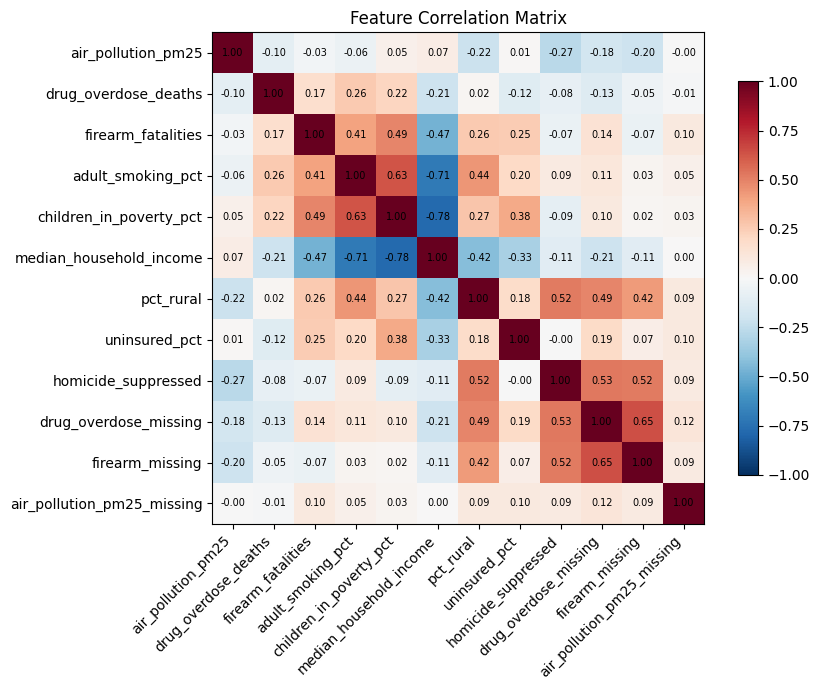

In [45]:
import matplotlib.pyplot as plt

feature_cols = ['air_pollution_pm25','drug_overdose_deaths','firearm_fatalities',
                'adult_smoking_pct','children_in_poverty_pct','median_household_income',
                'pct_rural','uninsured_pct','homicide_suppressed','drug_overdose_missing',
                'firearm_missing','air_pollution_pm25_missing']
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Correlation Matrix — Conclusion

Two groups of features move together:

- **Socioeconomic group:** income, poverty, and smoking are strongly linked
  (income↔poverty −0.78, income↔smoking −0.71, poverty↔smoking +0.63). They
  measure different sides of the same thing — a county's economic status.

- **Rural/missingness group:** the suppression flags track rurality
  (homicide_suppressed↔pct_rural +0.52, overdose_missing↔firearm_missing +0.65),
  confirming the flags act as markers for small rural counties.

**Takeaway:** because these features overlap, individual coefficients can't be
read as separate effects. Since the goal is prediction — not measuring each
factor alone — this overlap doesn't hurt the results, but it's noted as a
limitation.

Modeling - Y Target

In [46]:
y = df['low_birthweight_pct']

In [47]:
print(y.shape)

(3035,)


X features dropped  

In [48]:


X = df.drop(columns=['fipscode', 'state', 'county',
                     'low_birthweight_pct', 'high_lbw',
                     'drug_overdose_deaths_log', 'firearm_fatalities_log'])

In [49]:
print(X.shape)          # should be (3035, 12)


(3035, 12)


In [50]:
X.columns.tolist()      # eyeball: no fipscode, no targets, no _log columns

['air_pollution_pm25',
 'drug_overdose_deaths',
 'firearm_fatalities',
 'adult_smoking_pct',
 'children_in_poverty_pct',
 'median_household_income',
 'pct_rural',
 'uninsured_pct',
 'homicide_suppressed',
 'drug_overdose_missing',
 'firearm_missing',
 'air_pollution_pm25_missing']

split for this regression run — no stratify:
Random 42

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

All four line up correctly:

X_train (2428, 12) ↔ y_train (2428,) → 2428 rows match ✓
X_test (607, 12) ↔ y_test (607,) → 607 rows match ✓
2428 + 607 = 3035 → every county accounted for, none lost or duplicated ✓
Split is ~80/20 (2428/3035 = 80.0%) ✓
Both X pieces kept all 12 features ✓

In [52]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(2428, 12) (607, 12)
(2428,) (607,)


The scaler learns its mean and std from training rows only, so the test set contributes nothing to how the data is scaled — keeping the test set truly unseen and the final score honest.

In [53]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learns mean/std AND applies
X_test_scaled  = scaler.transform(X_test)    # applies only, no learning

Verification

In [54]:
import numpy as np
print("Train mean:", np.round(X_train_scaled.mean(), 4))
print("Train std: ", np.round(X_train_scaled.std(), 4))
print("Test mean: ", np.round(X_test_scaled.mean(), 4))
print("Test std:  ", np.round(X_test_scaled.std(), 4))

Train mean: 0.0
Train std:  1.0
Test mean:  0.0124
Test std:   0.9887


X: scaled (for both Dummy and real model, for fair comparison — though Dummy ignores it)
y: unscaled, always (real percentage units)

Restate it for yourself: the Dummy ignores the features, so scaling doesn't affect it — we use scaled X only to keep the comparison identical to the real model; and y is never scaled either way.

In [55]:
from sklearn.dummy import DummyRegressor

In [56]:
# 1. Instantiate the model to predict the mean
dummy_reg = DummyRegressor(strategy='mean')

# 2. Fit the dummy regressor on the training data
dummy_reg.fit(X_train_scaled, y_train)

# 3. Score the model on the test data
test_score = dummy_reg.score(X_test_scaled, y_test)

print(f"Dummy Regressor R² Score: {test_score:.4f}")

Dummy Regressor R² Score: -0.0015


The model

In [57]:
from sklearn.linear_model import LinearRegression

In [58]:


# 1. Create the model
lin_reg = LinearRegression()

# 2. Fit on the training data (features + answers)
lin_reg.fit(X_train_scaled, y_train)

# 3. Score on the test data
test_score = lin_reg.score(X_test_scaled, y_test)
print(f"Linear Regression R² Score: {test_score:.4f}")

Linear Regression R² Score: 0.4788


Drop Log columns to re split and re scale and test log1p

In [59]:
X_log = df.drop(columns=['fipscode', 'state', 'county',
                         'low_birthweight_pct', 'high_lbw',
                         'drug_overdose_deaths', 'firearm_fatalities'])

In [60]:
print(X_log.shape)          # (3035, 12)
X_log.columns.tolist()      # should show ..._log columns, NOT the raw two

(3035, 12)


['air_pollution_pm25',
 'adult_smoking_pct',
 'children_in_poverty_pct',
 'median_household_income',
 'pct_rural',
 'uninsured_pct',
 'homicide_suppressed',
 'drug_overdose_missing',
 'firearm_missing',
 'air_pollution_pm25_missing',
 'firearm_fatalities_log',
 'drug_overdose_deaths_log']

In [61]:
#Split
X_train_log, X_test_log, y_train, y_test = train_test_split(
X_log, y, test_size=0.2, random_state=42)

In [62]:
#Scale
scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_test_log_scaled  = scaler_log.transform(X_test_log)

Fit + score a fresh LR LOG1P
"log1p produced a marginal improvement (0.4788 → 0.4885); given the small magnitude and the interpretability cost of logged features, [raw is retained for interpretability / cross-validation was used to confirm]."

In [63]:
lin_reg_log = LinearRegression()
lin_reg_log.fit(X_train_log_scaled, y_train)
log_score = lin_reg_log.score(X_test_log_scaled, y_test)
print(f"Log Linear Regression R² Score: {log_score:.4f}")

Log Linear Regression R² Score: 0.4885


Cross validation on both LR and LR log1p

In [64]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

# RAW features: scaler + model bundled so scaling re-fits per fold
pipe_raw = make_pipeline(StandardScaler(), LinearRegression())
cv_raw = cross_val_score(pipe_raw, X, y, cv=5, scoring='r2')

# LOG features: same pipeline, log feature set
pipe_log = make_pipeline(StandardScaler(), LinearRegression())
cv_log = cross_val_score(pipe_log, X_log, y, cv=5, scoring='r2')

print("RAW  folds:", np.round(cv_raw, 4))
print("RAW  mean:", round(cv_raw.mean(), 4), "| std:", round(cv_raw.std(), 4))
print("LOG  folds:", np.round(cv_log, 4))
print("LOG  mean:", round(cv_log.mean(), 4), "| std:", round(cv_log.std(), 4))

RAW  folds: [0.3439 0.5614 0.5221 0.5045 0.1906]
RAW  mean: 0.4245 | std: 0.1385
LOG  folds: [0.3704 0.5603 0.5242 0.5062 0.1967]
LOG  mean: 0.4316 | std: 0.1339


 "5-fold CV showed log1p offered no meaningful improvement (0.4245 vs 0.4316, a difference far smaller than the 0.14 fold-to-fold std). Raw features were retained for interpretability. Notably, R² ranged from 0.19 to 0.56 across folds, indicating the exposure–birthweight relationship varies substantially by county subset."

CV Table

In [65]:
import pandas as pd

cv_table = pd.DataFrame({
    'Fold': ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'],
    'Raw R²': np.round(cv_raw, 4),
    'Log R²': np.round(cv_log, 4),
    'Log − Raw': np.round(cv_log - cv_raw, 4)
})

# add mean and std rows
summary = pd.DataFrame({
    'Fold': ['Mean', 'Std'],
    'Raw R²': [round(cv_raw.mean(), 4), round(cv_raw.std(), 4)],
    'Log R²': [round(cv_log.mean(), 4), round(cv_log.std(), 4)],
    'Log − Raw': [round((cv_log - cv_raw).mean(), 4), round((cv_log - cv_raw).std(), 4)]
})

cv_table = pd.concat([cv_table, summary], ignore_index=True)

cv_table.set_index('Fold')

,Raw R²,Log R²,Log − Raw
Fold,,,
Fold 1,0.3439,0.3704,0.0265
Fold 2,0.5614,0.5603,-0.0011
Fold 3,0.5221,0.5242,0.0021
Fold 4,0.5045,0.5062,0.0017
Fold 5,0.1906,0.1967,0.0061
Mean,0.4245,0.4316,0.0071
Std,0.1385,0.1339,0.0100


Building GNB y feature is y_clf = df['high_lbw'],

```
# This is formatted as code
X = df.drop(columns=['fipscode', 'state', 'county',
                     'low_birthweight_pct', 'high_lbw',
                     'drug_overdose_deaths_log', 'firearm_fatalities_log'])
```



In [66]:
y_clf = df['high_lbw']

X = df.drop(columns=['fipscode', 'state', 'county',
                     'low_birthweight_pct', 'high_lbw',
                     'drug_overdose_deaths_log', 'firearm_fatalities_log'])

Verify X.shape, y_clf.shape, and class balance (y_clf.value_counts())

In [67]:
print(X.shape)        # (3035, 12)
print(y_clf.shape)    # (3035,)
print(y_clf.value_counts())   # confirm the ~50/50 class balance

(3035, 12)
(3035,)
high_lbw
1    1519
0    1516
Name: count, dtype: int64


#the stratified split stratify=y_clf
Why: high_lbw is a binary class, and stratify keeps the same 0/1 ratio in train and test. Classes are ~50/50 not badly imbalanced.

In [68]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [69]:
# Verify split
print(X_train_clf.shape, X_test_clf.shape)
print(y_train_clf.value_counts(normalize=True).round(3))
print(y_test_clf.value_counts(normalize=True).round(3))

(2428, 12) (607, 12)
high_lbw
1    0.5
0    0.5
Name: proportion, dtype: float64
high_lbw
1    0.501
0    0.499
Name: proportion, dtype: float64


#tandardize — fresh scaler
Fit on the new training rows only.  Use to avoid leakage, re-fit because these are different rows than the regression split:

## AI NOTE
(One note worth knowing: GaussianNB doesn't strictly need standardization the way distance-based models do — it estimates a mean and variance per feature per class regardless of scale. But scaling doesn't hurt it, and it keeps your pipeline consistent with the regression run and clean for the dummy comparison. So we scale for consistency, not necessity — same reasoning as "scale the dummy even though it ignores X.")

In [70]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled  = scaler_clf.transform(X_test_clf)

In [71]:
# Numpy and check scaler_clf
import numpy as np
print("Train mean:", np.round(X_train_clf_scaled.mean(), 4))
print("Train std: ", np.round(X_train_clf_scaled.std(), 4))

Train mean: 0.0
Train std:  1.0


#Build DummyClassifier
Baseline (floor ~0.50) before the real GNB.

In [72]:
from sklearn.dummy import DummyClassifier

# 1. create
dummy_clf = DummyClassifier(strategy='most_frequent')
# 2. fit on training data
dummy_clf.fit(X_train_clf_scaled, y_train_clf)
# 3. score on test data
dummy_score = dummy_clf.score(X_test_clf_scaled, y_test_clf)
print(f"Dummy Classifier Accuracy: {dummy_score:.4f}")

Dummy Classifier Accuracy: 0.5008


DCA = 50.08%.  GNB has to clear DCA meaningfully to prove the features carry signal for classification.

## AI Note
(Quick read on the number: it's 0.5008 rather than exactly 0.50 because the test set is 0.501/0.499 — the majority class is 1, and always guessing 1 gets you the 50.08% that are actually 1. Makes sense.)

In [73]:
#GaussianNB  y_clf = df['high_lbw']

from sklearn.naive_bayes import GaussianNB

# 1. create
gnb = GaussianNB()
# 2. fit on training data
gnb.fit(X_train_clf_scaled, y_train_clf)
# 3. score on test data
gnb_score = gnb.score(X_test_clf_scaled, y_test_clf)
print(f"GaussianNB Accuracy: {gnb_score:.4f}")

GaussianNB Accuracy: 0.7595


GNB = 0.7595 vs 0.5008 floor. The GNB is ~26 points above the dummy, so the features carry real classification signal. Knowing a county's pollution, poverty, smoking, overdose/firearm rates, and the missingness flags lets you correctly call "high vs. low birthweight burden" about 76% of the time, versus 50% from guessing.  Determine if the result is accurate and not false positve

#Confusion matrix


In [74]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = gnb.predict(X_test_clf_scaled)

print(confusion_matrix(y_test_clf, y_pred))
print()
print(classification_report(y_test_clf, y_pred, digits=3))

[[239  64]
 [ 82 222]]

              precision    recall  f1-score   support

           0      0.745     0.789     0.766       303
           1      0.776     0.730     0.753       304

    accuracy                          0.759       607
   macro avg      0.760     0.760     0.759       607
weighted avg      0.760     0.759     0.759       607



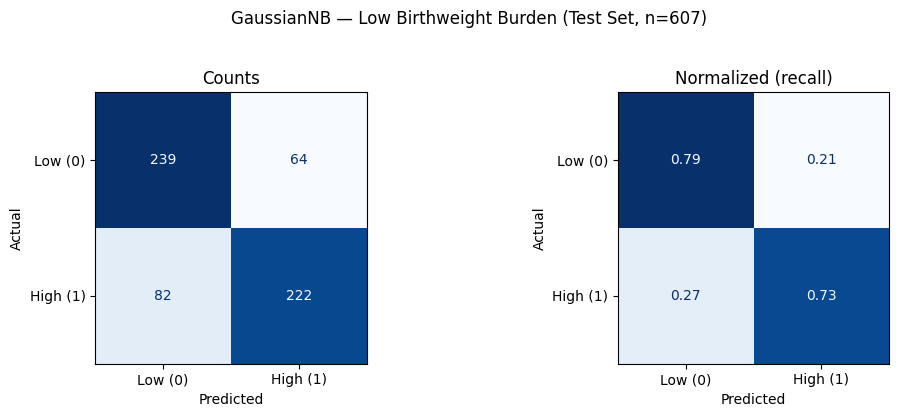

In [75]:
# Confusion Matrix heat map
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))   # 1 row, 2 columns

# LEFT — raw counts
ConfusionMatrixDisplay.from_estimator(
    gnb, X_test_clf_scaled, y_test_clf,
    display_labels=['Low (0)', 'High (1)'],
    cmap='Blues', colorbar=False, ax=axes[0]
)
axes[0].set_title('Counts')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# RIGHT — normalized (row = actual class, so diagonal = recall)
ConfusionMatrixDisplay.from_estimator(
    gnb, X_test_clf_scaled, y_test_clf,
    display_labels=['Low (0)', 'High (1)'],
    cmap='Blues', colorbar=False, normalize='true', ax=axes[1]
)
axes[1].set_title('Normalized (recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

fig.suptitle('GaussianNB — Low Birthweight Burden (Test Set, n=607)', y=1.03)
plt.tight_layout()
plt.show()

# Follow-up: Isolating Air Pollution

Checking correlation 2×2 table

```
df[['air_pollution_pm25', 'low_birthweight_pct']].corr()
```



In [76]:
df[['air_pollution_pm25', 'low_birthweight_pct']].corr()

,air_pollution_pm25,low_birthweight_pct
air_pollution_pm25,1.000000,0.048557
low_birthweight_pct,0.048557,1.000000


Finding
low_birthweight_pct: 0.0486 — the raw correlation between air pollution and low birthweight.

Essentially zero. On the −1 to +1 scale, 0.05 is weak — no meaningful linear relationship between a county's PM2.5 level and its low-birthweight rate, looking at air pollution alone.

standardized coefficients

In [78]:
import pandas as pd
coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefs)

children_in_poverty_pct       1.448509
firearm_fatalities            0.387647
homicide_suppressed          -0.343831
adult_smoking_pct            -0.189056
median_household_income       0.171353
air_pollution_pm25           -0.102964
pct_rural                    -0.101785
uninsured_pct                -0.094731
firearm_missing              -0.055826
air_pollution_pm25_missing   -0.055243
drug_overdose_missing        -0.040530
drug_overdose_deaths          0.030560
dtype: float64


#Scatter plot

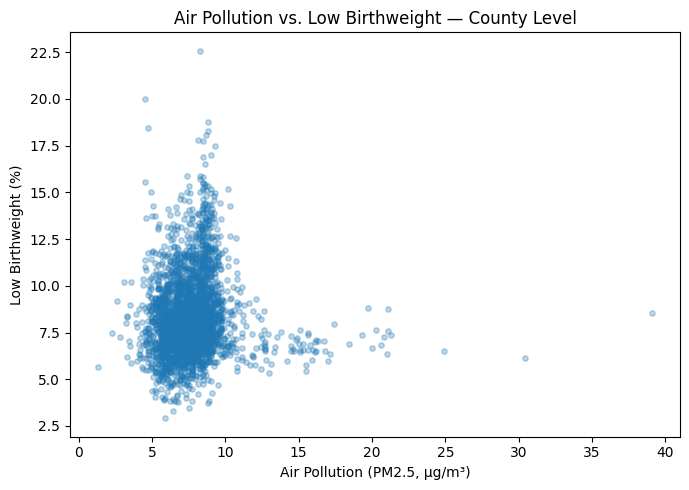

In [79]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(df['air_pollution_pm25'], df['low_birthweight_pct'], alpha=0.3, s=15)
plt.xlabel('Air Pollution (PM2.5, µg/m³)')
plt.ylabel('Low Birthweight (%)')
plt.title('Air Pollution vs. Low Birthweight — County Level')
plt.tight_layout()
plt.show()

### Finding — Air Pollution and Low Birthweight

Air pollution (PM2.5) shows **no meaningful relationship** with low birthweight
at the county level:

- Direct correlation: **0.05** (essentially zero)
- Regression coefficient: **−0.10** (small, after accounting for other factors)
- Scatter plot: a shapeless cloud, no visible trend

**Poverty is the dominant driver** (coefficient 1.45 — nearly 4× any other
feature). Air pollution ranks near the bottom.

Note: some coefficient signs (income, smoking) are counterintuitive because
those features are collinear with poverty. Individual coefficients should not
be read as isolated effects — this is a predictive model, not a causal one.

#Finding
### Confusion Matrix — GaussianNB

GNB accuracy **0.76** vs. dummy floor **0.50** → the features carry real
classification signal.

The model is **balanced across classes** (recall: low 0.79, high 0.73), so
the 0.76 accuracy is honest, not inflated by class imbalance.

**Limitation:** 82 of 304 high-burden counties were missed (recall 0.73).
In a resource-allocation context these are struggling counties that would
be overlooked — the costlier error type for public health.

# Conclusion

Using CHR 2025 data (3,035 counties), two models tested whether social and
environmental factors predict low birthweight.

**Regression (continuous target):** R² 0.48 vs. dummy floor ~0.00 — the
features explain about 48% of the variation in county low-birthweight rates.
Cross-validation confirmed the signal is real but varies by region (fold R²
ranged 0.19–0.56). log1p on the skewed columns gave no meaningful gain, so
raw features were kept for interpretability.

**Classification (high vs. low burden):** GaussianNB accuracy 0.76 vs. dummy
floor 0.50. The model is balanced across classes (recall: low 0.79, high 0.73),
so the accuracy is honest, not inflated. It misses ~27% of high-burden counties
— the costlier error type for public health.

**Both models beat their baselines**, confirming the features carry genuine
predictive signal for low birthweight.

**Limitations:**
- Features are correlated (income/poverty/smoking cluster), so individual
  effects can't be isolated — this is a predictive model, not a causal one.
- ~52% of the variation is unexplained; other factors (healthcare access,
  genetics, individual behavior) are not in the data.
- Results are county-level associations, not individual-level or causal claims.

#APPENDIX

In [77]:
# ============================================================
# APPENDIX — Publish cleaned dataset to Hugging Face
# ============================================================
!pip install -q huggingface_hub

from huggingface_hub import login, create_repo, upload_file

# 1. Authenticate — paste your WRITE token into the box that appears.
#    Do NOT type the token into this cell.
login()

REPO_ID = "RaayGunz/county-health-maternal-clean"

# 2. Create the repo (safe if it already exists)
create_repo(REPO_ID, repo_type="dataset", private=False, exist_ok=True)

# 3. Save the cleaned dataframe to CSV
df.to_csv("county_health_maternal_clean.csv", index=False)
# chr_data_dictionary.csv was already written by the data-dictionary cell

# 4. Write the data card (README.md)
readme = r"""---
license: cc-by-nc-4.0
language:
  - en
tags:
  - health
  - maternal-health
  - public-health
  - county-level
  - united-states
pretty_name: County Health — Maternal/Infant Health (Cleaned)
---

# County Health — Maternal / Infant Health (Cleaned)

A cleaned, modeling-ready county-level dataset for predicting low birthweight
from social and environmental factors. Derived from County Health Rankings &
Roadmaps (CHR&R) 2025.

## What's in it
- **3,035 U.S. counties**, 19 columns
- **Target:** `low_birthweight_pct` (percent of live births under 2,500g)
- **Binary target:** `high_lbw` (above/below median split)
- **Features:** air pollution (PM2.5), drug overdose deaths, firearm fatalities,
  adult smoking, children in poverty, median household income, percent rural,
  uninsured percent
- **Engineered missingness flags:** homicide_suppressed, drug_overdose_missing,
  firearm_missing, air_pollution_pm25_missing
- **Log transforms:** drug_overdose_deaths_log, firearm_fatalities_log

A full data dictionary is included as `chr_data_dictionary.csv`.

## Cleaning summary
- Promoted the 2025 file's stacked measure-code header; dropped US/state rollup rows
- Unit reconciliation: four proportion columns x100 to percent scale
- **homicide_rate** (53% missing, MNAR suppression in small rural counties):
  dropped continuous column, kept a binary suppression flag
- **drug_overdose, firearm, air_pollution:** median-imputed with missingness flags
- Dropped 8 Connecticut counties (Census replaced CT counties with planning
  regions; county-level values are blank)
- Final frame certified: 0 missing values

## Results (in the accompanying analysis)
- **Regression:** R^2 0.48 vs. dummy floor ~0.00 (real signal; varies by region,
  fold R^2 0.19-0.56)
- **GaussianNB classification:** accuracy 0.76 vs. dummy floor 0.50, balanced
  across classes (recall low 0.79 / high 0.73)

## Limitations
- Features are correlated (income/poverty/smoking cluster); this is a predictive
  model, not a causal one - individual effects cannot be isolated
- ~52% of variation is unexplained (healthcare access, genetics, individual
  behavior not included)
- County-level associations only; not individual-level or causal claims

## License & Source
Derived from County Health Rankings & Roadmaps 2025 (University of Wisconsin
Population Health Institute). Source data is subject to the CHR&R Terms of Use
(https://www.countyhealthrankings.org/terms-use), which **prohibit commercial
use** - including training AI models offered as commercial products - without
CHR&R's express written consent.

This cleaned/derived dataset is shared for **educational and non-commercial
research purposes only**. Users must comply with CHR&R's original terms. For
commercial use, contact info@countyhealthrankings.org.

**Citation:** University of Wisconsin Population Health Institute. County Health
Rankings & Roadmaps 2025. countyhealthrankings.org
"""

with open("README.md", "w") as f:
    f.write(readme)

# 5. Upload all three files
for fname in ["county_health_maternal_clean.csv",
              "chr_data_dictionary.csv",
              "README.md"]:
    upload_file(
        path_or_fileobj=fname,
        path_in_repo=fname,
        repo_id=REPO_ID,
        repo_type="dataset",
    )
    print(f"Uploaded {fname}")

print(f"\nDone → https://huggingface.co/datasets/{REPO_ID}")

ERROR: Operation cancelled by user


KeyboardInterrupt: 